# Lassa seroreactivity — paper figure notebook

This notebook contains only the analyses and plots needed for the current paper story.

**Core narrative**
1. Population level: identify the most prevalent seroreactive viral genuses across viral families.
2. Individual level: show how those species-level responses are distributed across Lassa fever survivors, household contacts, and US healthy controls.
3. Outcome: test whether selected viral species distinguish survivors from household contacts.
4. Sequence mechanism: use exact 8-aa sequence linkage to visualize representative cross-species peptide clusters containing *Mammarenavirus lassaense* and *Orthonairovirus haemorrhagiae*.
5. Merge ELISA data with PhIP-Seq seroreactivity data.

The standardized master peptide library is the sole peptide annotation/reference file used downstream. Original annotations are retained in that file, while standardized ICTV 2025 taxonomy and protein annotations are used for analysis and plotting.

In [1]:

# 0. IMPORTS AND CONFIGURATION


import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx

from collections import defaultdict
from itertools import combinations
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
from matplotlib.lines import Line2D

sns.set_context('notebook')
sns.set_style('white')

# Input files -

Z_SL_FILE = 'z_score_df_SL_over_US_090226.csv'
Z_HBDB_FILE = 'z_hbdb_loo_results_090226.csv'
RPK_SL_FILE = './preprocessing/earliest_tp_rpk_avg_value_for_cohort_techreps_071626.csv'
RPK_HBDB_FILE = './preprocessing/hbdb_pass_100k_techreps_averaged_071626.csv'
LASV_ELISA_FILE = '../LASV_ELISA_Neut_and_PhIP_Seq_result_corrected_w_month_year_filtered_first_tp.csv'
REFERENCE_PEPTIDE_FILE = 'lassa_library_sequences_species_standardized_070726_ICTV_corrected.csv'


# Analysis thresholds -

Z_THRESH = 3
SENS_MIN = 0.05
SPEC_MIN = 0.99

# Remove taxa/accessions excluded from the original downstream analysis
TAXA_TO_REMOVE = ['Trypanosomatidae', 'Konkoviridae']
ACCESSIONS_TO_REMOVE = ['WAK75154.1', 'ANT96597.1'] #accessions mapping to ampicillin resistance proteins found in vaccine constructs

# Heatmap selection
TOP_N_PER_FAMILY = 2

# Network targets
TARGET_LASSA = 'Mammarenavirus lassaense'
TARGET_HAEM = 'Orthonairovirus haemorrhagiae'

FIG_DIR = './paper_figures'

## 1. Load standardized peptide reference and z-score matrices

Only the standardized master peptide library is used to supply peptide sequence, accession, ICTV species/genus/family, and standardized protein information. The z-score files provide the participant-level seroreactivity measurements.

In [2]:

# 1. LOAD INPUTS -


import os
os.makedirs(FIG_DIR, exist_ok=True)

# Participant z-scores
df_sl_z = pd.read_csv(Z_SL_FILE).set_index('peptide')
df_hbdb_z = pd.read_csv(Z_HBDB_FILE).set_index('peptide')

# participant rpk values
df_sl_rpk = pd.read_csv(RPK_SL_FILE).set_index('peptide')
df_hbdb_rpk = pd.read_csv(RPK_HBDB_FILE).set_index('peptide')

### 2. Define the filtered high-specificity peptide set

A peptide is considered reactive when its participant-level z-score is >3. Peptides retained for the downstream viral analysis have ≥5% sensitivity in the SL cohort and ≥99% specificity in HBDB, followed by the same exclusion of non-target taxa/artificial-vector accessions used previously.

In [3]:

# 2. PEPTIDE-LEVEL FILTERING -


pass_sl = df_sl_z > Z_THRESH
pass_hbdb = df_hbdb_z > Z_THRESH

peptide_stats = pd.DataFrame({
    'sensitivity': pass_sl.mean(axis=1),
    'specificity': 1 - pass_hbdb.mean(axis=1)
})


hits = peptide_stats[
    (peptide_stats['sensitivity'] >= SENS_MIN) &
    (peptide_stats['specificity'] >= SPEC_MIN)
].copy()

hits = pd.DataFrame(hits).reset_index('peptide')

print(hits.peptide.nunique(), 'before exclusion of taxa and accessions')


1292 before exclusion of taxa and accessions


In [4]:
peps_metadata = pd.read_csv(REFERENCE_PEPTIDE_FILE)
peps_metadata.rename(columns={'seq_id':'peptide'}, inplace=True)

In [5]:
hits = hits.merge(peps_metadata, on='peptide', how='left')

In [6]:
hits.head(1)
hits.columns.to_list()

['peptide',
 'sensitivity',
 'specificity',
 'sequence',
 'accession',
 'protein_name',
 'gene',
 'segment',
 'order',
 'family',
 'subfamily',
 'genus',
 'species',
 'isolate',
 'taxonomy_lineage',
 'collection_date',
 'geo_loc_name',
 'host',
 'protein_std',
 'fragment',
 'collection_date_standardized']

In [7]:
hits.to_csv('pep_hits_090726.csv')


### from those peptide hits I want to add the ICTV recognized and standardized species name, and standardize the protein it belongs to e.g. nucleoprotein, NP, capsid --> nucleoprotein

In [8]:

# Original analysis exclusions
hits = hits[
    ~hits['family'].isin(TAXA_TO_REMOVE)
].copy()

hits = hits[
    ~hits['accession'].isin(ACCESSIONS_TO_REMOVE)
].copy()


print(f'Filtered peptide hits: {hits.peptide.nunique()}')
print(f'Unique standardized species: {hits.species.nunique()}')
print(f'Unique standardized genera: {hits.genus.nunique()}')
print(f'Unique standardized families: {hits.family.nunique()}')

Filtered peptide hits: 1274
Unique standardized species: 366
Unique standardized genera: 42
Unique standardized families: 9


In [9]:
hits['accession'].nunique()

797

In [10]:
hits.to_csv('pep_hits_wo_taxa_to_remove_090726.csv')

In [11]:

# 3. LONG-FORM PARTICIPANT DATA -

df_z = pd.concat([df_sl_z, df_hbdb_z], axis=1)
df_rpk = pd.concat([df_sl_rpk, df_hbdb_rpk], axis=1)

z_long = (
    df_z.loc[hits['peptide']]
    .reset_index()
    .melt(
        id_vars='peptide',
        var_name='individual',
        value_name='z_score'
    )
)

rpk_long = (
    df_rpk.loc[hits['peptide']]
    .reset_index()
    .melt(
        id_vars='peptide', 
        var_name='individual', 
        value_name='rpk'
    )
)

long = z_long.merge(
    rpk_long, 
    on=['peptide', 'individual'], 
    how='left'
)


long = long.merge(
    hits[
        [
            'peptide', 'sequence', 'species', 'genus', 'family',
            'protein_std', 'accession'
        ]
    ].drop_duplicates('peptide'),
    on='peptide',
    how='left'
)

long['cohort'] = np.where(
    z_long['individual'].str.startswith('HBDB-'),
    'HBDB',
    'SL'
)

long['category'] = np.select(
    [
        long['individual'].str.startswith('S-'),
        long['individual'].str.startswith('C-'),
        long['individual'].str.startswith('HBDB-')
    ],
    [
        'Lassa survivor',
        'Household contact',
        'US healthy'
    ],
    default='Unknown'
)

long['reactive'] = long['z_score'] > Z_THRESH


print(long['category'].nunique())

3


In [12]:
long.to_csv('long_090726.csv')

In [12]:
long.columns.to_list()

['peptide',
 'individual',
 'z_score',
 'rpk',
 'sequence',
 'species',
 'genus',
 'family',
 'protein_std',
 'accession',
 'cohort',
 'category',
 'reactive']

# Figure 1 — Population-level viral seroreactivity

**Question:** Which viral genuses show the highest seroreactive prevalence in the exposed Sierra Leone population, and how does that compare with the US healthy reference?

For each viral family, the genus with the highest SL seroreactive prevalence is selected. The final displayed genuses are ranked by SL prevalence. This keeps the figure focused on taxonomic breadth.

In [ ]:
# FIGURE 1:
# GENUS-LEVEL SEROREACTIVITY + PEPTIDE-LEVEL DEPTH
#
# Panel A = genus-level seroprevalence
# Panel B = number of reactive peptides among seropositive
#            SL individuals
#
# Genus selection:
#   one representative genus per viral family,
#   defined as the genus with the highest SL seroprevalence
#
# Ordering:
#   identical genus order in both panels
#   highest SL seroprevalence at the TOP
#
# Family:
#   shown once to the left of Panel A
#
# Peptide reactivity:
#   z-score > 3

# 0. IMPORTS -

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = long.groupby(
    ['family', 'genus', 'cohort', 'individual'], 
    observed=True, )['reactive'].any().reset_index(name='genus_seroreactive')

#then calculate prevalence
genus_prevalence = (
    df
    .groupby(
        ['family', 'genus', 'cohort'], 
        observed=True
    )['genus_seroreactive'].mean()
    .reset_index(
        name='seroprevalence'
    )
    )

genus_prevalence_top = (
    genus_prevalence
    .sort_values(
        'seroprevalence', 
        ascending=False
    )
    .groupby(
        ['family', 'cohort'], 
        observed=True
    )
    .head(1)
    .reset_index(drop=True)
)

Number of viral families represented: 9


,family,genus,SL,HBDB
8,Phenuiviridae,Phlebovirus,1.000000,0.0
6,Nairoviridae,Orthonairovirus,1.000000,0.0
7,Arenaviridae,Mammarenavirus,1.000000,0.0
5,Hantaviridae,Orthohantavirus,1.000000,0.0
4,Flaviviridae,Orthoflavivirus,0.979849,0.0
3,Paramyxoviridae,Henipavirus,0.909320,0.0
2,Filoviridae,Orthoebolavirus,0.712846,0.0
1,Togaviridae,Alphavirus,0.173804,0.0
0,Matonaviridae,Rubivirus,0.062972,0.0


In [ ]:
# 11. PREPARE PANEL B:
# REACTIVE PEPTIDE DEPTH
#
# Among SL individuals who are seroreactive to each
# representative genus, count the number of UNIQUE reactive
# peptides mapping to that genus.

genus_order = genus_prevalence['genus']

representative_genera = set(
    genus_order
)

sl_genus = (
    long[
        (long['cohort'] == 'SL') &
        (long['genus'].isin(
            representative_genera
        ))
    ]
    .copy()
)


# Reactive peptides only --

sl_genus_reactive = (
    sl_genus[
        sl_genus['reactive']
    ]
    .copy()
)

# Count UNIQUE reactive peptides per individual x genus -

genus_depth = (
    sl_genus_reactive
    .groupby(
        [
            'genus',
            'individual'
        ],
        observed=True
    )['peptide']
    .nunique()
    .reset_index(
        name='n_reactive_peptides'
    )
)


# 13. MAKE SURE GENUS DEPTH ONLY CONTAINS SEROPOSITIVE PEOPLE

#
# Every row here already has >=1 reactive peptide, so every
# individual in this table is seropositive for that genus.


genus_depth['genus'] = pd.Categorical(
    genus_depth['genus'],
    categories=genus_order,
    ordered=True
)


# 14. MEDIAN DEPTH ---


depth_medians = (
    genus_depth
    .groupby(
        'genus',
        observed=True
    )['n_reactive_peptides']
    .median()
    .reindex(
        genus_order
    )
)

depth_iqrs = (
    genus_depth
    .groupby(
        'genus', 
        observed=True
    )['n_reactive_peptides']
    .agg(lambda x: x.quantile(0.75) - x.quantile(0.25))
    .reindex(
        genus_order
    )
)

ValueError: Categorical categories must be unique

In [16]:
depth_medians, depth_iqrs

(genus
 Rubivirus           1.0
 Alphavirus          1.0
 Orthoebolavirus     2.0
 Henipavirus         2.0
 Orthoflavivirus     4.0
 Orthohantavirus     9.0
 Orthonairovirus    21.0
 Mammarenavirus     21.0
 Phlebovirus        19.0
 Name: n_reactive_peptides, dtype: float64,
 genus
 Rubivirus           0.0
 Alphavirus          0.0
 Orthoebolavirus     1.0
 Henipavirus         2.0
 Orthoflavivirus     3.0
 Orthohantavirus     6.0
 Orthonairovirus    10.0
 Mammarenavirus     12.0
 Phlebovirus        10.0
 Name: n_reactive_peptides, dtype: float64)

In [18]:
representative_genus

,genus,HBDB,SL,family
0,Rubivirus,0.0,0.062972,Matonaviridae
1,Alphavirus,0.0,0.173804,Togaviridae
2,Orthoebolavirus,0.0,0.712846,Filoviridae
3,Henipavirus,0.0,0.909320,Paramyxoviridae
4,Orthoflavivirus,0.0,0.979849,Flaviviridae
5,Orthohantavirus,0.0,1.000000,Hantaviridae
6,Orthonairovirus,0.0,1.000000,Nairoviridae
7,Mammarenavirus,0.0,1.000000,Arenaviridae
8,Phlebovirus,0.0,1.000000,Phenuiviridae


/data1/sporak/anaconda3/envs/align3/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 64.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/data1/sporak/anaconda3/envs/align3/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 85.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/data1/sporak/anaconda3/envs/align3/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 86.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/data1/sporak/anaconda3/envs/align3/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 83.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/data1/sporak/an

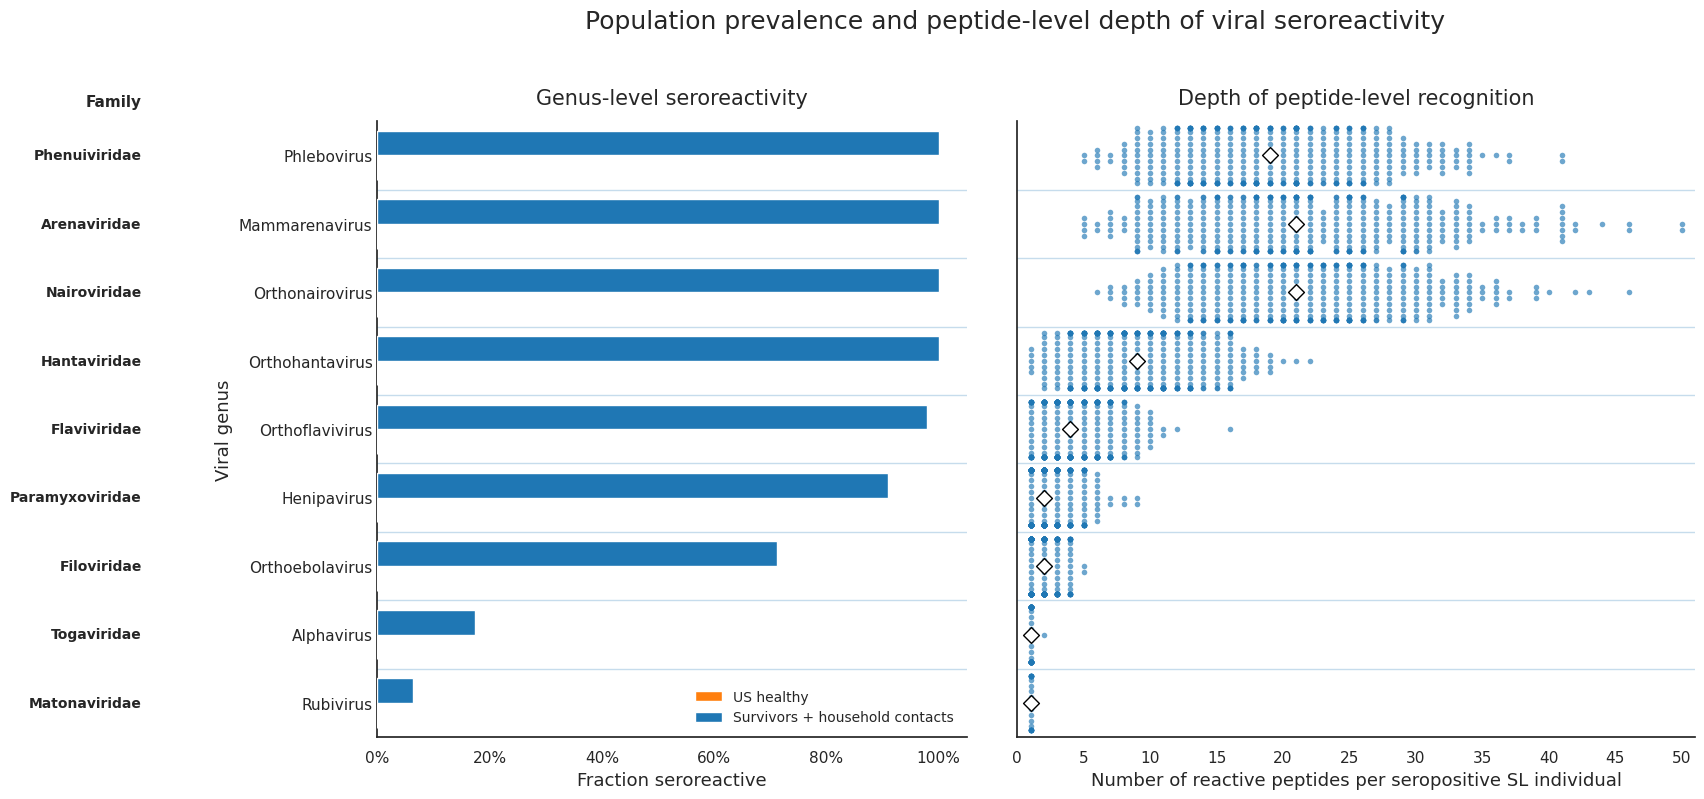

In [22]:
# 15. CREATE FIGURE
#
# sharey=True + exact same genus ordering guarantees that
# both panels occupy the same rows.


fig, axes = plt.subplots(
    1,
    2,
    figsize=(17, 8),
    sharey=True,
    gridspec_kw={
        'width_ratios': [
            1,
            1.15
        ],
        'wspace': 0.08
    }
)


# PANEL A

ax = axes[0]

y = np.arange(len(representative_genus))

bar_height = 0.36


# US healthy

if 'HBDB' in representative_genus.columns:

    ax.barh(
        y - bar_height / 2,
        representative_genus['HBDB'],
        height=bar_height,
        label='US healthy',
        zorder=3, 
        color="tab:orange"
    )


# SL

ax.barh(
    y + bar_height / 2,
    representative_genus['SL'],
    height=bar_height,
    label='Survivors + household contacts',
    zorder=3, 
    color="tab:blue"
)


# Genus labels

ax.set_yticks(y)

ax.set_yticklabels(
    representative_genus['genus'],
    fontsize=11
)


# X-axis formatting

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, pos: f'{x:.0%}'
    )
)

ax.set_xlabel(
    'Fraction seroreactive',
    fontsize=13
)

ax.set_ylabel(
    'Viral genus',
    fontsize=13
)

ax.set_title(
    'Genus-level seroreactivity',
    fontsize=15,
    pad=12
)


# Legend

ax.legend(
    frameon=False,
    loc='lower right',
    fontsize=10
)


# FAMILY LABELS
#
# Shown ONCE, to the left of Panel A.

for i, genus in enumerate(
    genus_order
):

    family = family_lookup[
        genus
    ]

    ax.text(
        -0.40,
        i,
        family,
        transform=ax.get_yaxis_transform(),
        ha='right',
        va='center',
        fontsize=10,
        fontweight='bold',
        clip_on=False
    )


# Family heading
ax.text(
    -0.40,
    1.02,
    'Family',
    transform=ax.transAxes,
    ha='right',
    va='bottom',
    fontsize=11,
    fontweight='bold',
    clip_on=False
)


# PANEL B

ax = axes[1]


sns.swarmplot(
    data=genus_depth,
    x='n_reactive_peptides',
    y='genus',

    # EXACT SAME ORDER AS PANEL A
    order=genus_order,

    size=4,
    alpha=0.65,
    ax=ax
)


# MEDIAN DIAMONDS -


for i, genus in enumerate(
    genus_order
):

    median = depth_medians.loc[
        genus
    ]

    if pd.notna(median):

        ax.scatter(
            median,
            i,
            marker='D',
            s=65,
            facecolor='white',
            edgecolor='black',
            linewidth=1,
            zorder=10
        )



# PANEL B X-AXIS
#
# Show ticks every 5 peptides

max_depth = int(
    genus_depth[
        'n_reactive_peptides'
    ].max()
)

ax.set_xticks(
    np.arange(
        0,
        max_depth + 5,
        5
    )
)

ax.set_xlim(
    0,
    max_depth + 1
)



# LABELS -


ax.set_xlabel(
    'Number of reactive peptides per seropositive SL individual',
    fontsize=13
)

ax.set_ylabel('')

ax.set_title(
    'Depth of peptide-level recognition',
    fontsize=15,
    pad=12
)



# 16. MAKE Y-AXIS ALIGNMENT EXPLICIT

#
# Panel A and Panel B both have the same y positions because:
#
#   Panel A -> representative_genus sorted ascending SL
#   Panel B -> order=genus_order
#   sharey=True
#
# No invert_yaxis() is required.


axes[0].set_ylim(
    -0.5,
    len(genus_order) - 0.5
)

axes[1].set_ylim(
    -0.5,
    len(genus_order) - 0.5
)



# 17. OPTIONAL FAMILY SEPARATORS
#
# Family names remain only on the left, but separators help
# visually group related genera across both panels.


family_sequence = [
    family_lookup[
        genus
    ]
    for genus in genus_order
]


for i in range(
    len(family_sequence) - 1
):

    if (
        family_sequence[i]
        != family_sequence[i + 1]
    ):

        boundary = i + 0.5

        axes[0].axhline(
            boundary,
            linewidth=1,
            alpha=0.25
        )

        axes[1].axhline(
            boundary,
            linewidth=1,
            alpha=0.25
        )



# 18. CLEAN UP


for ax in axes:

    sns.despine(
        ax=ax
    )

    ax.tick_params(
        axis='y',
        length=0
    )


# 19. OVERALL TITLE


fig.suptitle(
    (
        'Population prevalence and peptide-level depth '
        'of viral seroreactivity'
    ),
    fontsize=18,
    y=1.02
)



# 20. SAVE


plt.tight_layout()

fig.savefig(
    f'{FIG_DIR}/Figure1_genus_prevalence_and_depth.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Figure 2 — Individual viral seroreactivity heatmap

**Question:** How are the population-level signals distributed across individuals?

The two species with the highest SL seroreactive prevalence within each viral family are shown. Species are grouped by family and ordered within each family by SL prevalence. Individuals are grouped as **Lassa survivors → household contacts → US healthy**, with hierarchical clustering performed separately within each outcome/reference group using the complete species-level maximum z-score profile.

For clustering, Euclidean distance and Ward linkage are used. The dendrograms are not displayed; clustering only determines the order of individuals.


Representative genera from Figure 1: 9

SELECTED SPECIES
Phenuiviridae | Phlebovirus | Phlebovirus cacaoense | SL=59.9%
Phenuiviridae | Phlebovirus | Phlebovirus ntepesense | SL=59.4%
Phenuiviridae | Phlebovirus | Phlebovirus limboense | SL=57.7%
Nairoviridae | Orthonairovirus | Orthonairovirus haemorrhagiae | SL=94.7%
Nairoviridae | Orthonairovirus | Orthonairovirus erveense | SL=72.5%
Nairoviridae | Orthonairovirus | Orthonairovirus nairobiense | SL=70.8%
Arenaviridae | Mammarenavirus | Mammarenavirus lassaense | SL=99.0%
Arenaviridae | Mammarenavirus | Mammarenavirus choriomeningitidis | SL=85.1%
Arenaviridae | Mammarenavirus | Mammarenavirus lunaense | SL=61.5%
Hantaviridae | Orthohantavirus | Orthohantavirus hantanense | SL=49.9%
Hantaviridae | Orthohantavirus | Orthohantavirus artybashense | SL=36.8%
Hantaviridae | Orthohantavirus | Huangpi virus | SL=36.3%
Flaviviridae | Orthoflavivirus | Orthoflavivirus denguei | SL=94.5%
Flaviviridae | Orthoflavivirus | Orthoflavivirus zikaen

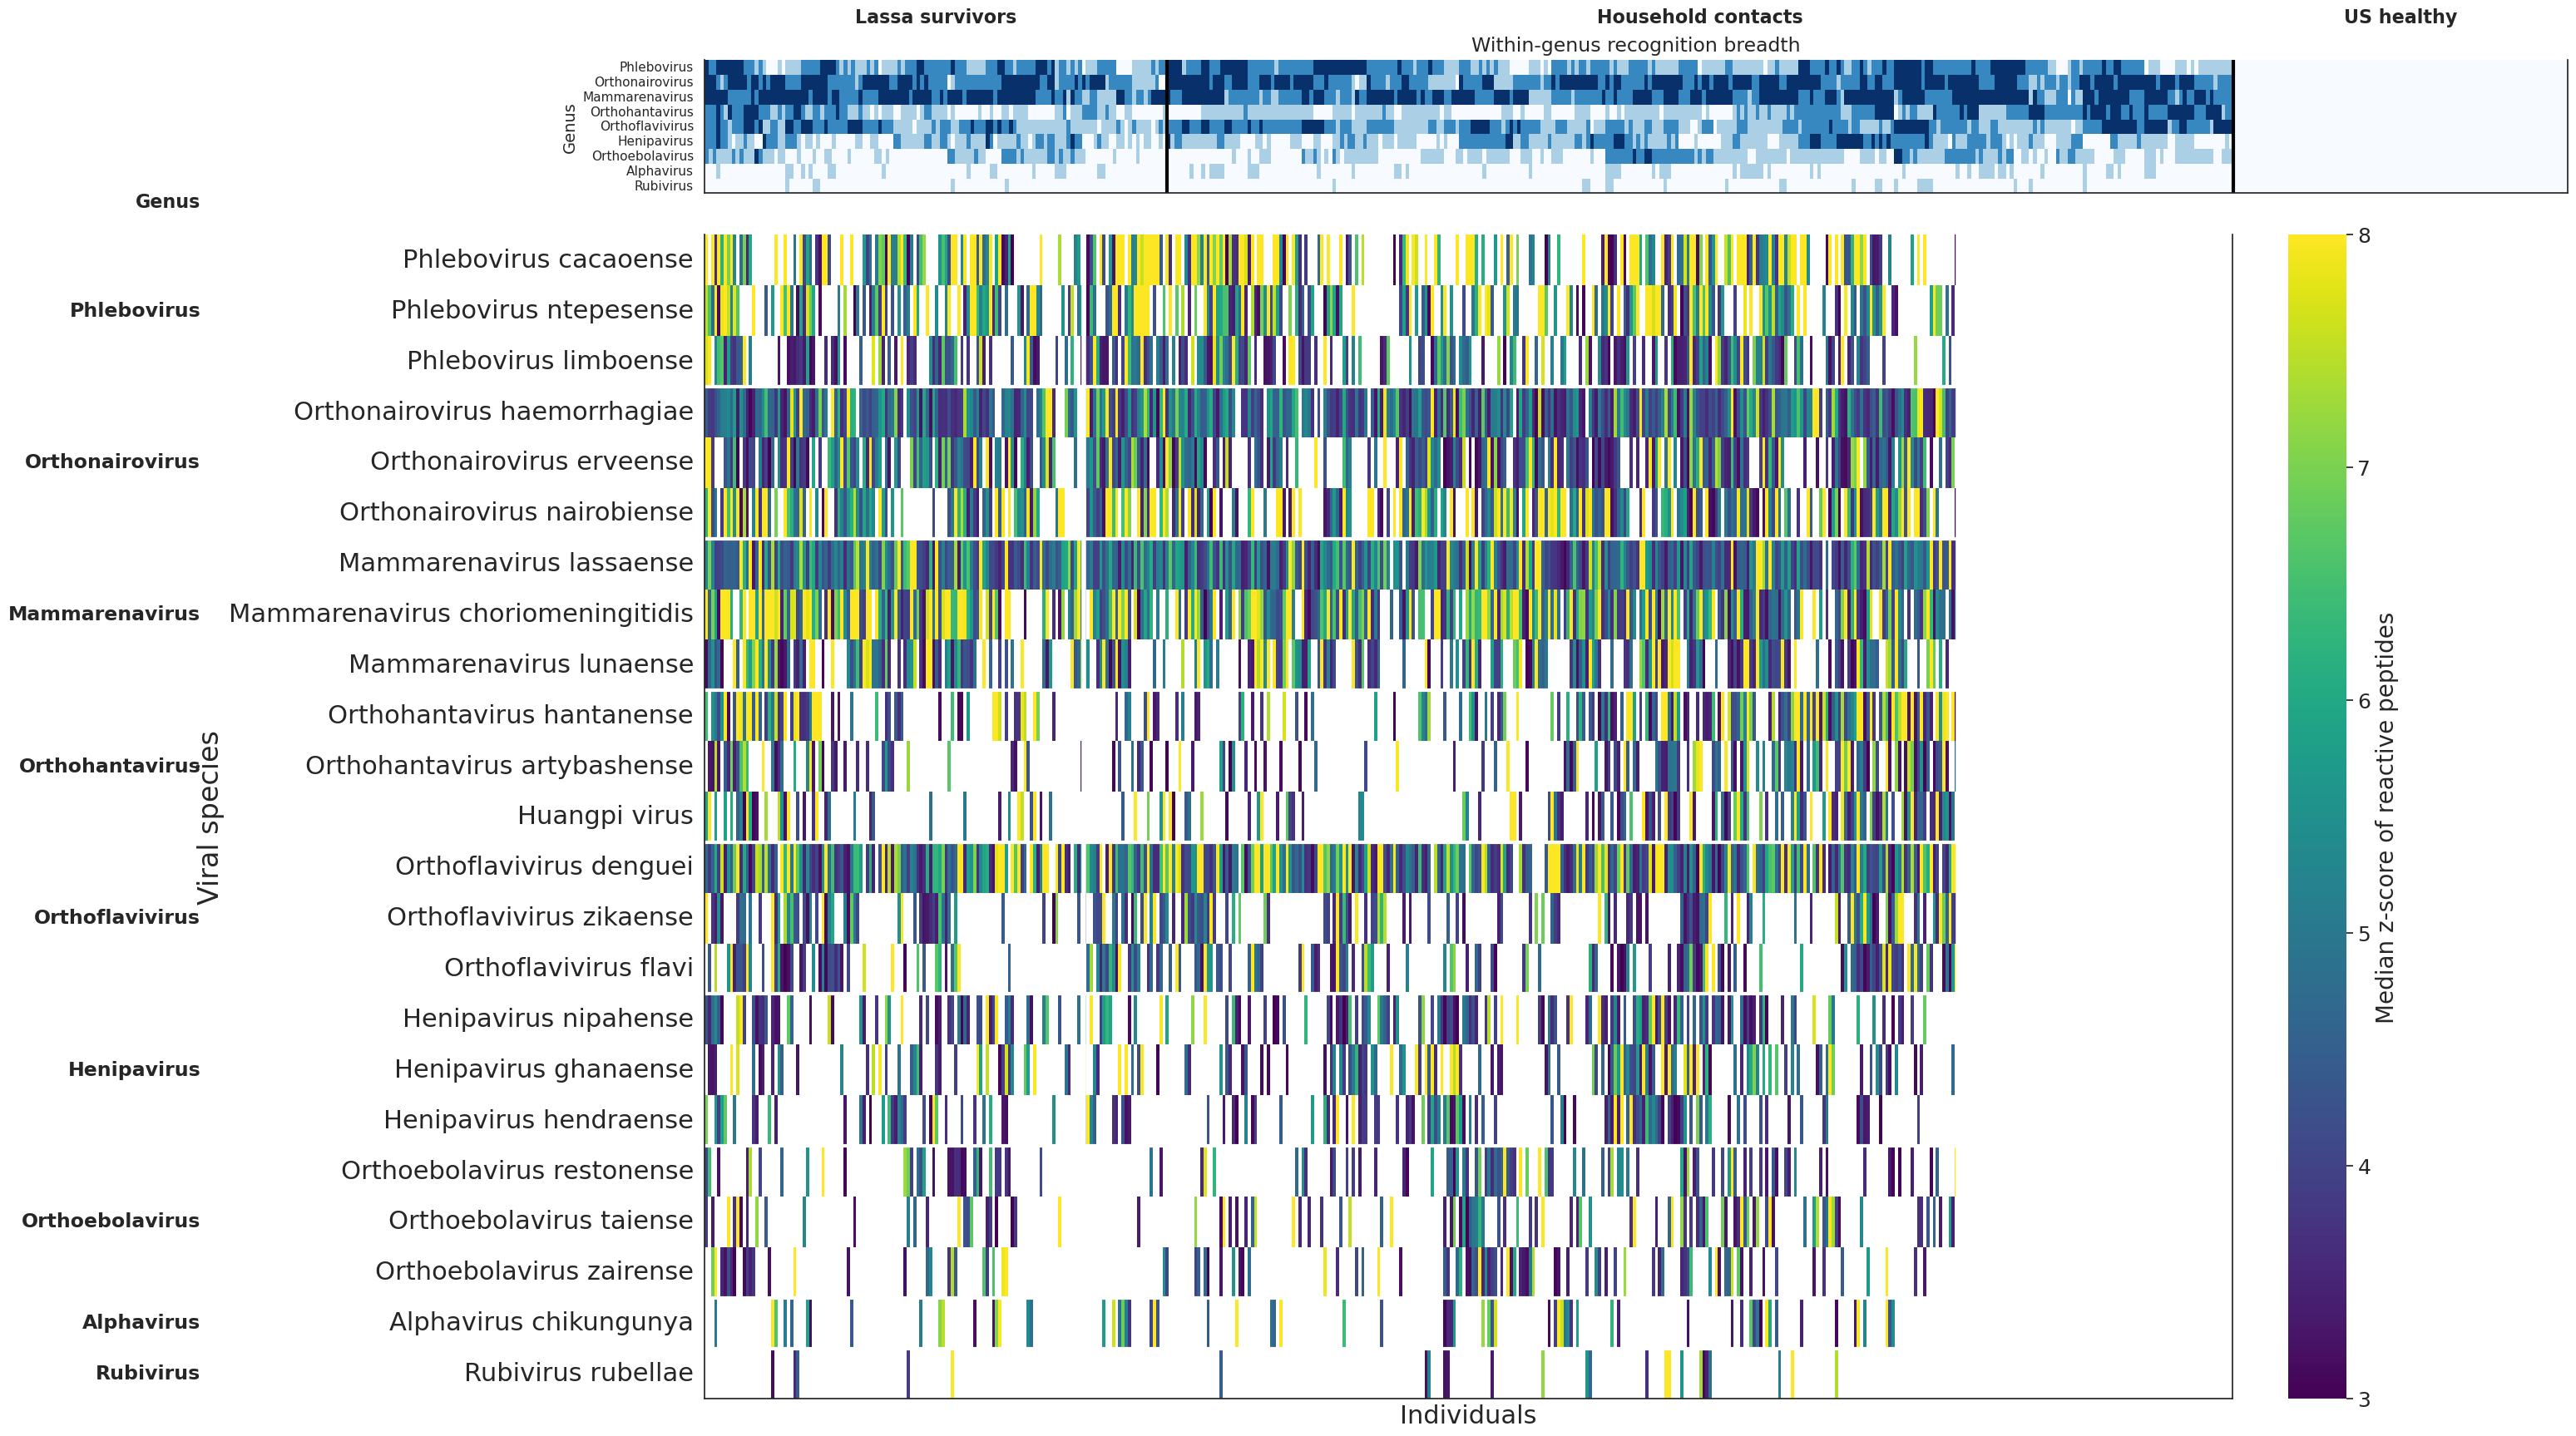


INDIVIDUAL RECOGNITION SUMMARY
                  n_genera_recognized                   \
                                count median      mean   
group                                                    
Household contact                 277    6.0  6.357401   
Lassa survivor                    120    6.0  5.991667   
US healthy                         87    0.0  0.000000   

                  n_genera_with_2plus_species                   
                                        count median      mean  
group                                                           
Household contact                         277    4.0  4.032491  
Lassa survivor                            120    4.0  3.725000  
US healthy                                 87    0.0  0.000000  


In [ ]:
# ============================================================
# FIGURE 2:
# INDIVIDUAL VIRAL SEROREACTIVITY HEATMAP
#
# MAIN HEATMAP VALUE:
#   Median z-score among reactive peptides
#   for each individual x species
#
# REACTIVITY:
#   peptide is reactive if z_score > 3
#
# SPECIES SELECTION:
#   Top 3 species within each Figure 1 representative genus,
#   ranked by SL seroprevalence
#
# INDIVIDUAL ORDERING:
#   Hierarchical clustering separately within each cohort,
#   based on within-genus recognition breadth
#
# WITHIN-GENUS RECOGNITION BREADTH:
#   Number of selected species within a genus recognized
#   by each individual
#
# Cohorts:
#   Lassa survivors
#   Household contacts
#   US healthy (HBDB)
#
# IMPORTANT:
#   Within-genus recognition breadth suggests broader recognition
#   but does NOT by itself demonstrate antibody cross-reactivity.
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import (
    linkage,
    leaves_list
)


# ============================================================
# 1. SETTINGS
# ============================================================

TOP_N_SPECIES_PER_GENUS = 3

# Peptide-level reactivity threshold
REACTIVE_Z_THRESHOLD = 3

# Heatmap color scale
HEATMAP_VMIN = REACTIVE_Z_THRESHOLD
HEATMAP_VMAX = 8

# Figure dimensions
FIGURE_WIDTH = 35
FIGURE_HEIGHT = 20


# ============================================================
# 2. COLLAPSE TO INDIVIDUAL x SPECIES
# ============================================================
#
# For each individual x species:
#
# median_reactive_z:
#     median z-score among REACTIVE peptides only
#
# n_reactive_peptides:
#     number of reactive peptides
#
# seroreactive:
#     TRUE if at least one peptide is reactive
#
# Why median among reactive peptides?
#
# Taking the median across ALL peptides would dilute a real
# peptide-specific response with many nonreactive peptides.
#
# Max z-score is avoided because one extreme peptide can dominate
# the species-level signal.
# ============================================================


def median_reactive_z(group):

    reactive_z = group.loc[
        group['reactive'],
        'z_score'
    ]

    if len(reactive_z) == 0:
        return np.nan

    return reactive_z.median()


species_individual = (
    long
    .groupby(
        [
            'species',
            'individual',
            'cohort',
            'genus',
            'family'
        ],
        observed=True
    )
    .apply(
        lambda g: pd.Series(
            {
                'median_reactive_z':
                    median_reactive_z(g),

                'n_reactive_peptides':
                    g['reactive'].sum(),

                'seroreactive':
                    g['reactive'].any()
            }
        ),
        include_groups=False
    )
    .reset_index()
)


# ============================================================
# 3. SPECIES PREVALENCE IN SL
# ============================================================
#
# This is used to select the top species within each
# representative genus.
# ============================================================

sl_species_prev = (
    species_individual[
        species_individual['cohort'] == 'SL'
    ]
    .groupby(
        [
            'species',
            'genus',
            'family'
        ],
        observed=True
    )[
        'seroreactive'
    ]
    .mean()
    .reset_index(
        name='SL_prevalence'
    )
)


# ============================================================
# 4. REPRESENTATIVE GENERA FROM FIGURE 1
# ============================================================

representative_genera = (
    representative_genus[
        'genus'
    ]
    .dropna()
    .unique()
    .tolist()
)


print(
    '\nRepresentative genera from Figure 1: '
    f'{len(representative_genera)}'
)


# ============================================================
# 5. KEEP SPECIES BELONGING TO FIGURE 1 GENERA
# ============================================================

species_candidates = (
    sl_species_prev[
        sl_species_prev['genus'].isin(
            representative_genera
        )
    ]
    .copy()
)


# ============================================================
# 6. SELECT TOP 3 SPECIES PER GENUS
# ============================================================
#
# Highest SL seroprevalence first.
# ============================================================

selected_species_df = (
    species_candidates
    .sort_values(
        [
            'genus',
            'SL_prevalence'
        ],
        ascending=[
            True,
            False
        ]
    )
    .groupby(
        'genus',
        observed=True,
        group_keys=False
    )
    .head(
        TOP_N_SPECIES_PER_GENUS
    )
    .copy()
)


# ============================================================
# 7. GENUS ORDER
# ============================================================
#
# Match Figure 1:
# descending SL genus-level seroprevalence.
# ============================================================

genus_order = (
    representative_genus
    .sort_values(
        'SL',
        ascending=False
    )[
        'genus'
    ]
    .tolist()
)


# Keep only genera represented in Figure 2

selected_genera = set(
    selected_species_df[
        'genus'
    ]
)


genus_order = [
    genus
    for genus in genus_order
    if genus in selected_genera
]


# ============================================================
# 8. SPECIES ORDER
# ============================================================
#
# First:
#     Figure 1 genus order
#
# Then within genus:
#     descending SL prevalence
# ============================================================

species_order = []


for genus in genus_order:

    genus_species = (
        selected_species_df[
            selected_species_df[
                'genus'
            ] == genus
        ]
        .sort_values(
            'SL_prevalence',
            ascending=False
        )[
            'species'
        ]
        .tolist()
    )

    species_order.extend(
        genus_species
    )


print(
    '\nSELECTED SPECIES'
)


for species in species_order:

    row = (
        selected_species_df[
            selected_species_df[
                'species'
            ] == species
        ]
        .iloc[0]
    )

    print(
        f"{row['family']} | "
        f"{row['genus']} | "
        f"{species} | "
        f"SL={row['SL_prevalence']:.1%}"
    )


# ============================================================
# 9. CREATE SPECIES x INDIVIDUAL MATRIX
# ============================================================
#
# DISPLAYED HEATMAP:
#
#     median z-score among reactive peptides
#
# Nonreactive individual x species combinations are NaN.
# ============================================================

heatmap_long = (
    species_individual[
        species_individual[
            'species'
        ].isin(
            species_order
        )
    ]
    .copy()
)


species_person_z = (
    heatmap_long
    .pivot(
        index='species',
        columns='individual',
        values='median_reactive_z'
    )
    .reindex(
        species_order
    )
)


# ============================================================
# 10. CREATE SPECIES x INDIVIDUAL REACTIVITY MATRIX
# ============================================================
#
# TRUE:
#     at least one reactive peptide
#
# FALSE:
#     no reactive peptides
#
# This is used to calculate within-genus recognition breadth.
# ============================================================

species_person_reactive = (
    heatmap_long
    .pivot(
        index='species',
        columns='individual',
        values='seroreactive'
    )
    .reindex(
        species_order
    )
    .fillna(False)
    .astype(bool)
)


# ============================================================
# 11. INDIVIDUAL -> COHORT
# ============================================================

individual_cohort = (
    heatmap_long[
        [
            'individual',
            'cohort'
        ]
    ]
    .drop_duplicates(
        'individual'
    )
    .set_index(
        'individual'
    )[
        'cohort'
    ]
)


# Keep only individuals actually represented in the matrix

individual_cohort = (
    individual_cohort[
        individual_cohort.index.isin(
            species_person_z.columns
        )
    ]
)


# Ensure exact same individual order

species_person_z = (
    species_person_z[
        individual_cohort.index
    ]
)


species_person_reactive = (
    species_person_reactive[
        individual_cohort.index
    ]
)


# ============================================================
# 12. DEFINE THREE GROUPS
# ============================================================
#
# cohort:
#     SL vs HBDB
#
# Within SL:
#     S- = survivor
#     C- = household contact
# ============================================================

survivor_individuals = (
    individual_cohort[
        (
            individual_cohort == 'SL'
        )
        &
        (
            individual_cohort.index
            .astype(str)
            .str.startswith('S-')
        )
    ]
    .index
    .tolist()
)


contact_individuals = (
    individual_cohort[
        (
            individual_cohort == 'SL'
        )
        &
        (
            individual_cohort.index
            .astype(str)
            .str.startswith('C-')
        )
    ]
    .index
    .tolist()
)


hbdb_individuals = (
    individual_cohort[
        individual_cohort == 'HBDB'
    ]
    .index
    .tolist()
)


# ============================================================
# 13. SANITY CHECK
# ============================================================

n_sl_total = (
    individual_cohort
    .eq('SL')
    .sum()
)


n_classified_sl = (
    len(survivor_individuals)
    +
    len(contact_individuals)
)


print(
    '\nCOHORT COUNTS'
)

print(
    f'All SL individuals: '
    f'{n_sl_total}'
)

print(
    f'Lassa survivors: '
    f'{len(survivor_individuals)}'
)

print(
    f'Household contacts: '
    f'{len(contact_individuals)}'
)

print(
    f'US healthy: '
    f'{len(hbdb_individuals)}'
)

print(
    f'Unclassified SL individuals: '
    f'{n_sl_total - n_classified_sl}'
)


# Show unexpected SL IDs

unclassified_sl = [
    x
    for x in individual_cohort[
        individual_cohort == 'SL'
    ].index

    if not (
        str(x).startswith('S-')
        or
        str(x).startswith('C-')
    )
]


if len(unclassified_sl) > 0:

    print(
        '\nWARNING: unexpected SL individual IDs:'
    )

    print(
        unclassified_sl[:20]
    )


# ============================================================
# 14. MAP SPECIES -> GENUS
# ============================================================

species_to_genus = (
    selected_species_df
    .drop_duplicates(
        'species'
    )
    .set_index(
        'species'
    )
    .loc[
        species_order,
        'genus'
    ]
)


# ============================================================
# 15. BUILD WITHIN-GENUS RECOGNITION BREADTH
# ============================================================
#
# For each genus x individual:
#
#     number of selected species recognized
#
# With three species per genus:
#
#     0 = no species recognized
#     1 = one species recognized
#     2 = two species recognized
#     3 = three species recognized
#
# This is used ONLY for clustering individuals.
#
# The displayed heatmap remains the median reactive
# peptide z-score.
# ============================================================

genus_breadth = (
    species_person_reactive
    .astype(int)
    .groupby(
        species_to_genus,
        observed=True
    )
    .sum()
)


# Match Figure 1 genus order

genus_breadth = (
    genus_breadth
    .reindex(
        genus_order
    )
)


print(
    '\nGENUS-LEVEL RECOGNITION BREADTH MATRIX'
)

print(
    f'Genera: '
    f'{genus_breadth.shape[0]}'
)

print(
    f'Individuals: '
    f'{genus_breadth.shape[1]}'
)


# ============================================================
# 16. SUMMARY METRICS
# ============================================================
#
# Number of genera where the individual recognizes:
#
#   >=1 species
#   >=2 species
#
# These are useful for interpretation / QC.
# ============================================================

n_genera_recognized = (
    genus_breadth
    .ge(1)
    .sum(
        axis=0
    )
)


n_broad_genera = (
    genus_breadth
    .ge(2)
    .sum(
        axis=0
    )


# ============================================================
# 17. CLUSTERING FUNCTION
# ============================================================
#
# Cluster individuals using genus-level recognition breadth.
#
# This means two individuals cluster together when they have
# similar patterns of:
#
#     0 / 1 / 2 / 3 recognized species
#
# across viral genera.
# ============================================================

def order_individuals_by_genus_breadth(
    individual_list
):

    if len(individual_list) == 0:

        return (
            [],
            None
        )


    # individuals x genera

    X = (
        genus_breadth[
            individual_list
        ]
        .fillna(0)
        .T
    )


    if X.shape[0] <= 1:

        return (
            X.index.tolist(),
            None
        )


    linkage_matrix = linkage(
        X,
        method='ward',
        metric='euclidean'
    )


    ordered_idx = (
        leaves_list(
            linkage_matrix
        )
    )


    ordered_individuals = (
        X.index[
            ordered_idx
        ]
        .tolist()
    )


    return (
        ordered_individuals,
        linkage_matrix
    )


# ============================================================
# 18. CLUSTER EACH COHORT SEPARATELY
# ============================================================

survivor_ordered, survivor_linkage = (
    order_individuals_by_genus_breadth(
        survivor_individuals
    )
)


contact_ordered, contact_linkage = (
    order_individuals_by_genus_breadth(
        contact_individuals
    )
)


hbdb_ordered, hbdb_linkage = (
    order_individuals_by_genus_breadth(
        hbdb_individuals
    )
)


# ============================================================
# 19. FINAL INDIVIDUAL ORDER
# ============================================================
#
# Survivors -> household contacts -> US healthy
# ============================================================

ordered_individuals = (
    survivor_ordered
    +
    contact_ordered
    +
    hbdb_ordered
)


# ============================================================
# 20. FINAL ORDER CHECK
# ============================================================

assert (
    len(ordered_individuals)
    ==
    len(species_person_z.columns)
)


assert (
    len(set(ordered_individuals))
    ==
    len(ordered_individuals)
)


print(
    '\nFINAL ORDER'
)

print(
    f'Survivors: '
    f'{len(survivor_ordered)}'
)

print(
    f'Household contacts: '
    f'{len(contact_ordered)}'
)

print(
    f'US healthy: '
    f'{len(hbdb_ordered)}'
)


# ============================================================
# 21. FINAL DISPLAY MATRIX
# ============================================================
#
# The displayed heatmap uses MEDIAN REACTIVE Z-SCORE.
#
# We only clip the upper end.
# We do NOT clip the lower end because all displayed values
# are already based on reactive peptides.
# ============================================================

plot_matrix = (
    species_person_z[
        ordered_individuals
    ]
    .clip(
        upper=HEATMAP_VMAX
    )
)


# ============================================================
# 22. ORDER GENUS BREADTH TO MATCH HEATMAP
# ============================================================

genus_breadth_plot = (
    genus_breadth[
        ordered_individuals
    ]
    .reindex(
        genus_order
    )
)


# ============================================================
# 23. SPECIES METADATA
# ============================================================

species_metadata = (
    selected_species_df
    .drop_duplicates(
        'species'
    )
    .set_index(
        'species'
    )
    .loc[
        plot_matrix.index
    ]
)


genus_sequence = (
    species_metadata[
        'genus'
    ]
    .tolist()
)


# ============================================================
# 24. FIND GENUS BLOCKS
# ============================================================

genus_blocks = []

current_genus = None
start = 0


for i, genus in enumerate(
    genus_sequence
):

    if genus != current_genus:

        if current_genus is not None:

            genus_blocks.append(
                (
                    current_genus,
                    start,
                    i - 1
                )
            )

        current_genus = genus
        start = i


if current_genus is not None:

    genus_blocks.append(
        (
            current_genus,
            start,
            len(genus_sequence) - 1
        )
    )


# ============================================================
# 25. COHORT BOUNDARIES
# ============================================================

n_survivor = len(
    survivor_ordered
)

n_contact = len(
    contact_ordered
)

n_hbdb = len(
    hbdb_ordered
)


boundary_survivor_contact = (
    n_survivor
)


boundary_contact_hbdb = (
    n_survivor
    +
    n_contact
)


# ============================================================
# 26. CREATE FIGURE
# ============================================================

fig = plt.figure(
    figsize=(
        FIGURE_WIDTH,
        FIGURE_HEIGHT
    )
)


# ============================================================
# 27. MAIN HEATMAP AXIS
# ============================================================

ax_heat = fig.add_axes(
    [
        0.18,
        0.10,
        0.64,
        0.70
    ]
)


# ============================================================
# 28. MAIN HEATMAP
# ============================================================
#
# Median z-score among reactive peptides.
# ============================================================

sns.heatmap(
    plot_matrix,

    ax=ax_heat,

    cmap='viridis',

    vmin=HEATMAP_VMIN,
    vmax=HEATMAP_VMAX,

    xticklabels=False,
    yticklabels=True,

    linewidths=0,

    cbar_kws={
        'label':
        'Median z-score of reactive peptides',

        'pad':
        0.03
    }
)


# ============================================================
# 29. SPECIES LABELS
# ============================================================

ax_heat.set_yticklabels(
    plot_matrix.index,
    fontsize=22,
    rotation=0
)


ax_heat.set_ylabel(
    'Viral species',
    fontsize=24
)


ax_heat.set_xlabel(
    'Individuals',
    fontsize=22
)


# ============================================================
# 30. COHORT BOUNDARIES
# ============================================================

if (
    n_survivor > 0
    and
    n_contact > 0
):

    ax_heat.axvline(
        boundary_survivor_contact,
        color='white',
        linewidth=4
    )


if (
    n_contact > 0
    and
    n_hbdb > 0
):

    ax_heat.axvline(
        boundary_contact_hbdb,
        color='white',
        linewidth=4
    )


# ============================================================
# 31. GENUS LABELS
# ============================================================
#
# One label centered across each genus block.
# ============================================================

for genus, start, end in genus_blocks:

    center = (
        start
        +
        end
        +
        1
    ) / 2


    ax_heat.text(
        -0.33,
        center,
        genus,

        transform=
        ax_heat.get_yaxis_transform(),

        ha='right',
        va='center',

        fontsize=17,
        fontweight='bold',

        clip_on=False
    )


# Genus heading

ax_heat.text(
    -0.33,
    1.02,
    'Genus',

    transform=ax_heat.transAxes,

    ha='right',
    va='bottom',

    fontsize=16,
    fontweight='bold',

    clip_on=False
)


# ============================================================
# 32. GENUS SEPARATORS
# ============================================================

for genus, start, end in genus_blocks[:-1]:

    ax_heat.axhline(
        end + 1,
        color='white',
        linewidth=3
    )


# ============================================================
# 33. MAIN TITLE
# ============================================================

ax_heat.set_title(
    (
        'Individual viral seroreactivity profiles\n'
        'Individuals ordered by within-genus recognition breadth'
    ),

    fontsize=28,
    pad=65
)


# ============================================================
# 34. COLORBAR
# ============================================================

cbar = (
    ax_heat
    .collections[0]
    .colorbar
)


cbar.ax.tick_params(
    labelsize=18
)


cbar.set_label(
    'Median z-score of reactive peptides',
    fontsize=20
)


# ============================================================
# 35. TOP ANNOTATION:
# WITHIN-GENUS RECOGNITION BREADTH
# ============================================================
#
# This annotation explains the clustering.
#
# For each genus x individual:
#
#   0 = recognizes 0 selected species
#   1 = recognizes 1 selected species
#   2 = recognizes 2 selected species
#   3 = recognizes 3 selected species
# ============================================================

ax_breadth = fig.add_axes(
    [
        0.18,
        0.825,
        0.64,
        0.08
    ]
)


sns.heatmap(
    genus_breadth_plot,

    ax=ax_breadth,

    cmap='Blues',

    vmin=0,
    vmax=TOP_N_SPECIES_PER_GENUS,

    xticklabels=False,
    yticklabels=True,

    linewidths=0,

    cbar=False
)


ax_breadth.set_yticklabels(
    genus_breadth_plot.index,
    fontsize=11,
    rotation=0
)


ax_breadth.set_ylabel(
    'Genus',
    fontsize=14
)


ax_breadth.set_xlabel(
    ''
)


ax_breadth.set_title(
    'Within-genus recognition breadth',
    fontsize=17,
    pad=8
)


# Cohort boundaries

if (
    n_survivor > 0
    and
    n_contact > 0
):

    ax_breadth.axvline(
        boundary_survivor_contact,
        color='black',
        linewidth=3
    )


if (
    n_contact > 0
    and
    n_hbdb > 0
):

    ax_breadth.axvline(
        boundary_contact_hbdb,
        color='black',
        linewidth=3
    )


# ============================================================
# 36. COHORT LABELS
# ============================================================

total_n = len(
    ordered_individuals
)


def x_to_axes_fraction(x):

    return (
        x / total_n
    )


# Lassa survivors

if n_survivor > 0:

    survivor_center = (
        n_survivor / 2
    )

    ax_breadth.text(
        x_to_axes_fraction(
            survivor_center
        ),
        1.25,

        'Lassa survivors',

        transform=ax_breadth.transAxes,

        ha='center',
        va='bottom',

        fontsize=16,
        fontweight='bold'
    )


# Household contacts

if n_contact > 0:

    contact_center = (
        n_survivor
        +
        n_contact / 2
    )

    ax_breadth.text(
        x_to_axes_fraction(
            contact_center
        ),
        1.25,

        'Household contacts',

        transform=ax_breadth.transAxes,

        ha='center',
        va='bottom',

        fontsize=16,
        fontweight='bold'
    )


# US healthy

if n_hbdb > 0:

    hbdb_center = (
        n_survivor
        +
        n_contact
        +
        n_hbdb / 2
    )

    ax_breadth.text(
        x_to_axes_fraction(
            hbdb_center
        ),
        1.25,

        'US healthy',

        transform=ax_breadth.transAxes,

        ha='center',
        va='bottom',

        fontsize=16,
        fontweight='bold'
    )


# ============================================================
# 37. CLEAN UP
# ============================================================

sns.despine(
    ax=ax_heat,
    right=False
)


sns.despine(
    ax=ax_breadth,
    right=False
)


# ============================================================
# 38. SAVE
# ============================================================

fig.savefig(
    f'{FIG_DIR}/Figure2_individual_species_heatmap_genus_breadth_medianZ.png',

    dpi=300,

    bbox_inches='tight'
)


plt.show()


# ============================================================
# 39. INDIVIDUAL SUMMARY TABLE
# ============================================================
#
# Useful for downstream analysis and QC.
# ============================================================

individual_summary = pd.DataFrame(
    {
        'individual':
        ordered_individuals
    }
)


individual_summary[
    'cohort'
] = (
    individual_summary[
        'individual'
    ]
    .map(
        individual_cohort
    )
)


def classify_group(individual):

    if (
        individual
        in survivor_individuals
    ):

        return 'Lassa survivor'

    elif (
        individual
        in contact_individuals
    ):

        return 'Household contact'

    elif (
        individual
        in hbdb_individuals
    ):

        return 'US healthy'

    else:

        return 'Unknown'


individual_summary[
    'group'
] = (
    individual_summary[
        'individual'
    ]
    .map(
        classify_group
    )
)


individual_summary[
    'n_genera_recognized'
] = (
    individual_summary[
        'individual'
    ]
    .map(
        n_genera_recognized
    )
)


individual_summary[
    'n_genera_with_2plus_species'
] = (
    individual_summary[
        'individual'
    ]
    .map(
        n_broad_genera
    )
)


print(
    '\nINDIVIDUAL RECOGNITION SUMMARY'
)


print(
    individual_summary
    .groupby(
        'group'
    )[
        [
            'n_genera_recognized',
            'n_genera_with_2plus_species'
        ]
    ]
    .agg(
        [
            'count',
            'median',
            'mean'
        ]
    )
)

# Figure 3: LASV ELISA data X PhIP-Seq seropositivity data 
**question:** does the LASV ELISA data reflect the seropositivity observed in the SL cohort? 
 an individual is defined LASV seropositive by PhIP-Seq, if at least one retained peptide passed z > 3. 

In [36]:
lasv_elisa_data = pd.read_csv(LASV_ELISA_FILE).set_index('species')
lasv_elisa_data.drop(columns='Unnamed: 0', inplace=True)

In [37]:
lasv = long[
    long['species'] == 'Mammarenavirus lassaense'
].copy()

lasv_seroreactive = (
    lasv.groupby('individual', as_index=False) #as_index =False to remain a regular column in the resulting dataframe
    .agg(
        n_LASV_reactive_peptides=('reactive', 'sum'),
        LASV_seroreactive=('reactive', 'any')
    )
)

In [38]:
lasv_concordance = lasv_elisa_data.merge(
    lasv_seroreactive, 
    on='individual', 
    how='left'
)

#match Negative / Positive from ELISA data
lasv_concordance['PhIP-Seq result'] = (
    lasv_concordance['LASV_seroreactive']
    .map({True: 'Positive', False:'Negative'})
)

In [39]:
lasv_concordance.groupby('Serology_Result_Corrected')[
    'n_LASV_reactive_peptides'
].agg(['count', 'median', 'mean', 'std', 'min', 'max'])

,count,median,mean,std,min,max
Serology_Result_Corrected,,,,,,
Negative,50,5.0,5.200000,3.458205,0,14
Positive,347,7.0,7.677233,4.517100,0,27


In [40]:
lasv_concordance.groupby('Serology_Result_Corrected')[
    'n_LASV_reactive_peptides'
].agg(
    n='count',
    median='median',
    Q1=lambda x: x.quantile(0.25),
    Q3=lambda x: x.quantile(0.75)
)

,n,median,Q1,Q3
Serology_Result_Corrected,,,,
Negative,50,5.0,3.0,6.0
Positive,347,7.0,4.0,10.0


In [ ]:
from scipy.stats import mannwhitneyu

neg = lasv_concordance.loc[
    lasv_concordance['Serology_Result_Corrected'] == 'Negative',
    'n_LASV_reactive_peptides'
]

pos = lasv_concordance.loc[
    lasv_concordance['Serology_Result_Corrected'] == 'Positive',
    'n_LASV_reactive_peptides'
]

mannwhitneyu(pos, neg, alternative='two-sided')

MannwhitneyuResult(statistic=np.float64(11624.0), pvalue=np.float64(9.698789032538046e-05))

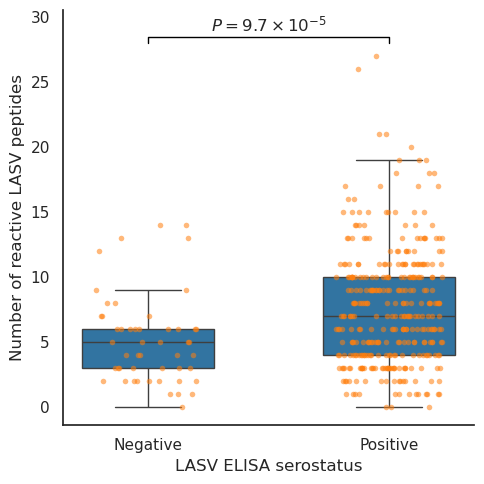

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(5, 5))

order = ['Negative', 'Positive']

sns.boxplot(
    data=lasv_concordance,
    x='Serology_Result_Corrected',
    y='n_LASV_reactive_peptides',
    order=order,
    showfliers=False,
    width=0.55,
    ax=ax
)

sns.stripplot(
    data=lasv_concordance,
    x='Serology_Result_Corrected',
    y='n_LASV_reactive_peptides',
    order=order,
    jitter=0.22,
    alpha=0.55,
    size=4,
    ax=ax
)

ax.set_xlabel('LASV ELISA serostatus')
ax.set_ylabel('Number of reactive LASV peptides')

# Statistical annotation
ymax = lasv_concordance['n_LASV_reactive_peptides'].max()
y = ymax + 1

ax.plot([0, 0, 1, 1], [y, y+0.4, y+0.4, y], c='black', lw=1)
ax.text(
    0.5, y + 0.6,
    r'$P = 9.7 \times 10^{-5}$',
    ha='center',
    va='bottom'
)

ax.set_ylim(top=y + 2.5)

sns.despine()
plt.tight_layout()
plt.show()

### now address cross-reactivity issue

# Figure 4 — Sequence-linked peptide networks

**Question:** Could multi-species seroreactivity reflect shared sequence features among viral peptide targets?

The network is built from **all filtered peptides**, not only those displayed in the heatmap. Two peptides are connected when they share an exact 8-amino-acid k-mer; connected components define sequence-linked peptide clusters.

We then select two biologically targeted examples, while first focusing on the **Mammarenavirus genus** as a follow up study to the heatmap, where cross-species reactivity was observed. 


Node color = species; node shape = standardized protein class; node size = fraction of SL individuals with z>3 for that peptide. Peptide labels are deliberately omitted for readability.

In [ ]:

# FIGURE 4: BUILD ALL-PEPTIDE 8-MER NETWORK -

K = 7

def get_kmers(sequence, k=K):
    sequence = str(sequence).upper()
    if len(sequence) < k:
        return set()
    return {
        sequence[i:i+k]
        for i in range(len(sequence) - k + 1)
    }


# Map k-mer -> peptides
# this creates an empty dictionary where the key will be the 8-mer, and the values the peptides containing it
kmer_to_peptides = defaultdict(list)

for peptide, sequence in (
    #itertuples allows you to loop through rows of a dataframe which columns defined, returning a tuple
    hits[['peptide', 'sequence']].itertuples(index=False)
):
    for kmer in get_kmers(sequence):
        kmer_to_peptides[kmer].append(peptide)

# Build graph
G_seq = nx.Graph()

for _, row in hits.iterrows():
    G_seq.add_node(
        row['peptide'],
        sequence=row['sequence'],
        species=row['species'],
        genus=row['genus'],
        family=row['family'],
        protein_name=row['protein_std'], #here protein_std will be named protein_name in the connected graph
        sl_prevalence=row['sensitivity']
    )

for kmer, peptides in kmer_to_peptides.items():
    peptides = list(set(peptides))
    if len(peptides) < 2: #need to have at least 2 peptides mapping to a kmer to form an edge
        continue
    for p1, p2 in combinations(peptides, 2):
        if G_seq.has_edge(p1, p2):
            G_seq[p1][p2]['shared_kmers'].append(kmer)
        else:
            G_seq.add_edge(
                p1,
                p2,
                shared_kmers=[kmer]
            )

components_seq = list(
    nx.connected_components(G_seq)
)

print(f'Peptide nodes: {G_seq.number_of_nodes()}')
print(f'Edges: {G_seq.number_of_edges()}')
print(f'Connected components: {len(components_seq)}')

Peptide nodes: 1274
Edges: 1135
Connected components: 804


In [ ]:
# SELECT TARGET-CONTAINING CLUSTERS

def summarize_components(components, network_hits):
    records = []

    for cluster_id, component in enumerate(components):
        sub = network_hits[
            network_hits['peptide'].isin(component)
        ]

        species = sorted(
            sub['species'].dropna().unique().tolist()
        )
        genera = sorted(
            sub['genus'].dropna().unique().tolist()
        )
        families = sorted(
            sub['family'].dropna().unique().tolist()
        )
        proteins = sorted(
            sub['protein_std'].dropna().unique().tolist()
        )

        records.append({
            'cluster_id': cluster_id,
            'n_peptides': sub['peptide'].nunique(),
            'n_species': len(species),
            'n_genera': len(genera),
            'n_families': len(families),
            'species': species,
            'genera': genera,
            'families': families,
            'proteins': proteins
        })

    return pd.DataFrame(records)


cluster_summary = summarize_components(
    components_seq,
    hits
)


def select_target_cluster( #find clusters that contain the target species, 
    #contain at least two species but where all species belong to the target genus
    target_species,
    target_genus
):
    candidates = cluster_summary[
        cluster_summary['species'].apply(
            #does the cluster have the target species you are interested in?
            lambda x: target_species in x
        )
        &
        cluster_summary['genera'].apply(
            #asks if that cluster contains exactly one genus and if it is the target_genus
            lambda x: len(x) == 1 and x[0] == target_genus
        )
        &
        (cluster_summary['n_species'] >= 2)
    ].copy()

    if candidates.empty:
        return None, candidates

    candidates = (
        candidates
        .sort_values(
            ['n_species', 'n_peptides'], #highest number of species wins, then n_peptides comes second as criterion
            ascending=False
        )
        .reset_index(drop=True) #renumbers sorted rows with 0, 1, 2.. etc.
    )

    return candidates.iloc[0], candidates


mamma_selected, mamma_candidates = select_target_cluster(
    TARGET_LASSA,
    'Mammarenavirus'
)

if mamma_selected is None:
    raise ValueError(
        f'No cross-species Mammarenavirus cluster contains {TARGET_LASSA}.'
    )

print('Selected Mammarenavirus cluster:')
display(mamma_selected.to_frame().T)

print('Other qualifying Mammarenavirus clusters:')
display(mamma_candidates.head(10))


Selected Mammarenavirus cluster:


,cluster_id,n_peptides,n_species,n_genera,n_families,species,genera,families,proteins
0,2,14,8,1,1,"[Mammarenavirus bearense, Mammarenavirus calie...",[Mammarenavirus],[Arenaviridae],[glycoprotein]


Other qualifying Mammarenavirus clusters:


,cluster_id,n_peptides,n_species,n_genera,n_families,species,genera,families,proteins
0,2,14,8,1,1,"[Mammarenavirus bearense, Mammarenavirus calie...",[Mammarenavirus],[Arenaviridae],[glycoprotein]
1,158,9,5,1,1,"[Mammarenavirus amapariense, Mammarenavirus ca...",[Mammarenavirus],[Arenaviridae],[polymerase]
2,8,8,5,1,1,"[Mammarenavirus kwanzaense, Mammarenavirus las...",[Mammarenavirus],[Arenaviridae],[polymerase]
3,126,3,3,1,1,"[Mammarenavirus kwanzaense, Mammarenavirus las...",[Mammarenavirus],[Arenaviridae],[polymerase]
4,82,6,2,1,1,"[Mammarenavirus lassaense, Mammarenavirus wenz...",[Mammarenavirus],[Arenaviridae],[polymerase]
5,160,3,2,1,1,"[Mammarenavirus lassaense, Mammarenavirus mafi...",[Mammarenavirus],[Arenaviridae],[z protein]
6,68,2,2,1,1,"[Mammarenavirus lassaense, Mammarenavirus tami...",[Mammarenavirus],[Arenaviridae],[polymerase]


In [ ]:
mamma_pol = mamma_candidates.iloc[1]

In [ ]:
mamma_gly_np = mamma_candidates.iloc[5]

In [ ]:

# INSPECT THE PEPTIDE CONTENT OF THE SELECTED CLUSTERS

def inspect_cluster(cluster_row):
    component = components_seq[
        int(cluster_row['cluster_id'])
    ]

    return (
        hits[
            hits['peptide'].isin(component)
        ]
        [
            [
                'peptide',
                'sequence',
                'species',
                'genus',
                'family',
                'protein_std',
                'sensitivity'
            ]
        ]
        .sort_values(
            ['species', 'protein_std', 'peptide']
        )
        .reset_index(drop=True)
    )

mamma_data_gp = inspect_cluster(mamma_selected)
mamma_data_pol = inspect_cluster(mamma_pol)
mamma_gly_np = inspect_cluster(mamma_gly_np)

print('Mammarenavirus selected cluster')
display(mamma_data_gp)
display(mamma_data_pol)

Mammarenavirus selected cluster


,peptide,sequence,species,genus,family,protein_std,sensitivity
0,ADD60472.1|precursor|Mammarenavirus_bearense|?...,VHSLPKCWHVKNGSYLNESDFRNEWIIESDHLISEILAKEYEERQR,Mammarenavirus bearense,Mammarenavirus,Arenaviridae,glycoprotein,0.070529
1,YP_001649226.1|precursor|Mammarenavirus_bearen...,VHSLPKCWHVRNGSYLNESDFRNEWIIESDHLVSEILAKEYEERQK,Mammarenavirus bearense,Mammarenavirus,Arenaviridae,glycoprotein,0.073048
2,AAB58486.1|precursor|Pichinde_virus|temperatur...,LKQLAKIPYCNYTKFWYINDTITGRHSLPQCWLVHNGSYLNETHFK,Mammarenavirus caliense,Mammarenavirus,Arenaviridae,glycoprotein,0.052897
3,AFI42021.1|precursor|Mammarenavirus_choriomeni...,TVTPLISDQLLMRNHLRDLMGVPYCNSSKFWYLEHAKTGETSVPKC,Mammarenavirus choriomeningitidis,Mammarenavirus,Arenaviridae,glycoprotein,0.068010
4,WVH10120.1|precursor|Mammarenavirus_choriomeni...,TINSLISDQLLMRNHLRDLMGVPYCNYSKFWYLEHSKTNETSVPKC,Mammarenavirus choriomeningitidis,Mammarenavirus,Arenaviridae,glycoprotein,0.050378
5,YP_010839964.1|precursor|Kitale_virus|?|Grammo...,SKFWYLNDTRNGKTSLPKCWLISNGSYLNETHFSDQIEQEADNMIT,Mammarenavirus kitaleense,Mammarenavirus,Arenaviridae,glycoprotein,0.073048
6,AZI96059.1|precursor|Mammarenavirus_lassaense|...,YWYLNNTVTGKSSLPKCWLVSNGSYLNETHFSEDIEQQADNMITEM,Mammarenavirus lassaense,Mammarenavirus,Arenaviridae,glycoprotein,0.090680
7,AZI96476.1|precursor|Mammarenavirus_lassaense|...,DQLIMKNHLRDIMGIPYCNYSKYWYLNHTITGKTSLPRCWLVSNGS,Mammarenavirus lassaense,Mammarenavirus,Arenaviridae,glycoprotein,0.148615
8,AZI96488.1|precursor|Mammarenavirus_lassaense|...,DQLIMKNHLRDIMGIPYCNYSKYWYLNHTVTGKTSLPRCWLVSNGT,Mammarenavirus lassaense,Mammarenavirus,Arenaviridae,glycoprotein,0.168766
9,QWQ58036.1|precursor|Mammarenavirus_lunaense|A...,NDQLIIKNHLRDLMGIPYCNYSKFWYLNDTRNGKTSLPKCWKVSNN,Mammarenavirus lunaense,Mammarenavirus,Arenaviridae,glycoprotein,0.070529


,peptide,sequence,species,genus,family,protein_std,sensitivity
0,YP_001649216.1|protein|Amapari_virus|?|?|Brazi...,TDQIKCFEKFLEPKLEFGFFVVNPSLNGTLTKEQEDAMVGGVSKFF,Mammarenavirus amapariense,Mammarenavirus,Arenaviridae,polymerase,0.088161
1,QLA46853.1|L|Pichinde_virus|?|Nephelomys_albig...,NVSYLCHFITKETPDRLTDQIKCFEKFLEPKLKFDSVLVNPSNSME,Mammarenavirus caliense,Mammarenavirus,Arenaviridae,polymerase,0.078086
2,AZI95860.1|polymerase|Mammarenavirus_lassaense...,LNVSYMCHFITKETPDRLTDQIKCFEKFLEPKLEFGHVSVNPKDDA,Mammarenavirus lassaense,Mammarenavirus,Arenaviridae,polymerase,0.060453
3,AZU96888.1|polymerase|Mammarenavirus_lassaense...,KETPDRLTDQIKCFEKFLEPKLEFGHVSVNPKDDASEEELAEMVHN,Mammarenavirus lassaense,Mammarenavirus,Arenaviridae,polymerase,0.050378
4,QBX05734.1|protein|Mammarenavirus_lassaense|LF...,KETPDRLTDQVKCFEKFLEPKLEFGHVNVNPSDAATEEELEDMVYN,Mammarenavirus lassaense,Mammarenavirus,Arenaviridae,polymerase,0.068010
5,YP_009505806.1|polymerase|Mammarenavirus_loeie...,TPDRLTDQIKCFEKFLEPKLAFGSCIVNPKELSAPEELDDYYYGAD,Mammarenavirus loeiense,Mammarenavirus,Arenaviridae,polymerase,0.055416
6,YP_009505806.1|polymerase|Mammarenavirus_loeie...,SCIVNPKELSAPEELDDYYYGADKFLEKPSPLDPAETIFGKPGVNK,Mammarenavirus loeiense,Mammarenavirus,Arenaviridae,polymerase,0.095718
7,YP_003090217.1|polymerase|Morogoro_mammarenavi...,KETPDRLTDQIKCFEKYLEPKLEFDSLNVNPKESGDEEEKLLLLNS,Mammarenavirus mopeiaense,Mammarenavirus,Arenaviridae,polymerase,0.055416
8,YP_003090217.1|polymerase|Morogoro_mammarenavi...,FDSLNVNPKESGDEEEKLLLLNSAEKFLSKPDCLTGDTISYKQPGV,Mammarenavirus mopeiaense,Mammarenavirus,Arenaviridae,polymerase,0.055416


,peptide,sequence,species,genus,family,protein_std,sensitivity
0,AZI95897.1|protein|Mammarenavirus_lassaense|LA...,MGGKQTKSSKETDSPRASLIPDASHMGPQFCKSCWFENKGLVECNN,Mammarenavirus lassaense,Mammarenavirus,Arenaviridae,z protein,0.078086
1,AZI96306.1|protein|Mammarenavirus_lassaense|LA...,MGNRQAKSTKVDEHQRACLVPDASHLGPQFCKSCWFENRGLVECNN,Mammarenavirus lassaense,Mammarenavirus,Arenaviridae,z protein,0.052897
2,UUL71811.1|protein|Mafiga_mammarenavirus|TZ298...,MGNQTAKSDKQEGRANKTDTGVSDKRAEMIPDATYLGPQFCKSCWF,Mammarenavirus mafigaense,Mammarenavirus,Arenaviridae,z protein,0.161209


(0.596078431372549, 0.8745098039215686, 0.5411764705882353)
(0.596078431372549, 0.8745098039215686, 0.5411764705882353)


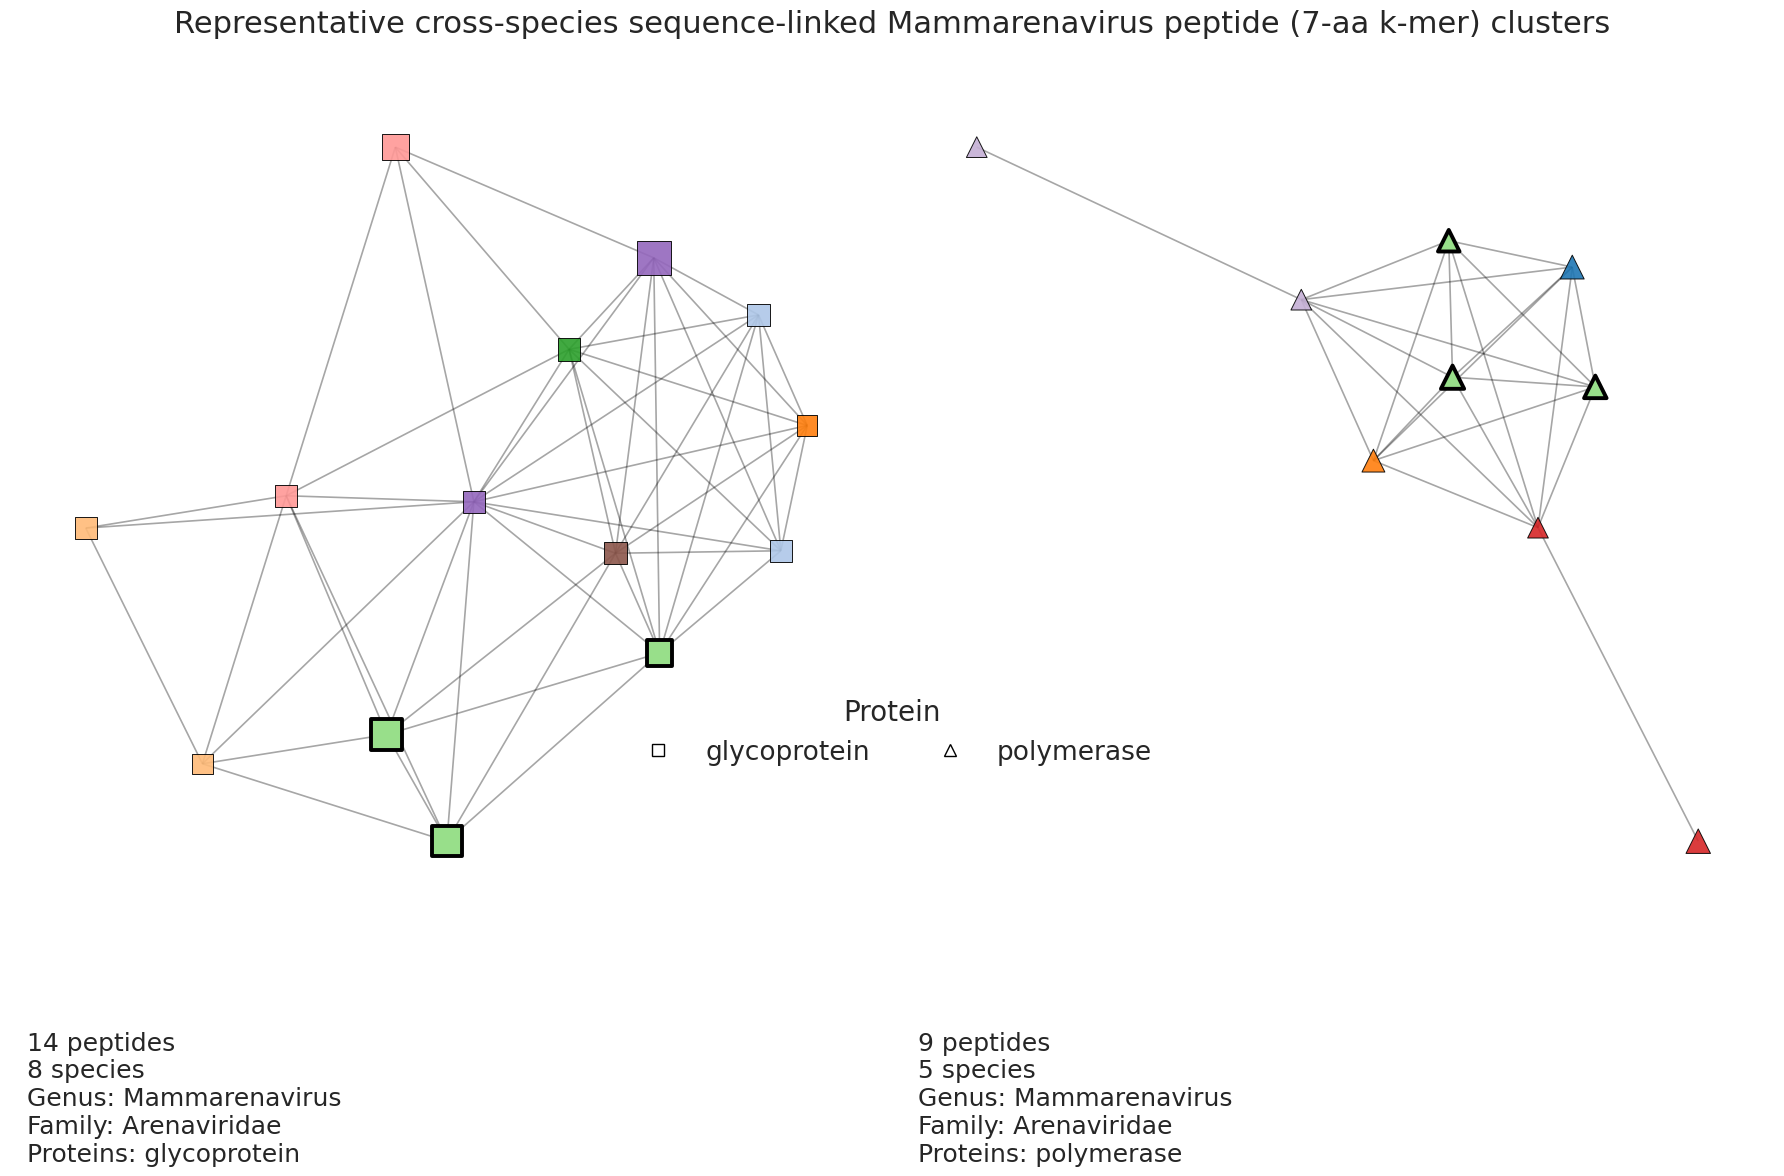

In [ ]:

# FIGURE 4 PLOT

protein_markers = {
   #'nucleoprotein': 'o',
    'glycoprotein': 's',
    'polymerase': '^',
   # 'matrix': 'D',
   # 'phosphoprotein': 'P',
   # 'nonstructural protein': 'v',
   # 'accessory protein': '<',
   # 'Other/Ambiguous': 'X'
}


def plot_cluster_network(ax, cluster_row, target_species, title):

    cluster_id = int(cluster_row['cluster_id'])
    component = components_seq[cluster_id]

    G = G_seq.subgraph(component).copy()

    G1_temp = G_seq.subgraph(
        components_seq[int(mamma_selected['cluster_id'])]
    )

    G2_temp = G_seq.subgraph(
    components_seq[int(mamma_pol['cluster_id'])]
)

    all_species = sorted(
        {
            G1_temp.nodes[node]['species']
            for node in G1_temp.nodes()
        }
        |
        {
            G2_temp.nodes[node]['species']
            for node in G2_temp.nodes()
        }
    )

    # One fixed color for each species across the entire figure
    tab20_colors = plt.cm.tab20.colors

    species_palette = {
        species: tab20_colors[i % 20]
        for i, species in enumerate(all_species)
    }

    visible_nodes = [
    node
    for node in G.nodes()
    if G.nodes[node]['protein_name'] in protein_markers
    ]

    species_here = sorted({
    G.nodes[node]['species']
    for node in visible_nodes
    })

    proteins_here = sorted({
        G.nodes[node]['protein_name']
        for node in visible_nodes
    })

    pos = nx.spring_layout( #nx.spring_layout() calculates where to place nodes when drawing a network
        G,
        seed=42,
        k=1.3,
        iterations=500
    )

    
    print(species_palette['Mammarenavirus lassaense'])

    # Edges
    nx.draw_networkx_edges( #draws edges
        G,
        pos,
        ax=ax,
        width=1.2,
        alpha=0.35
    )

    # Nodes: color = species, shape = standardized protein class
    for protein_type, marker in protein_markers.items():

        nodes = [
            node
            for node in G.nodes()
            if G.nodes[node]['protein_name'] == protein_type
        ]

        if not nodes:
            continue

        nx.draw_networkx_nodes(
            G,
            pos,
            ax=ax,
            nodelist=nodes,
            node_size=[
                100 + 2200 * G.nodes[node]['sl_prevalence']
                for node in nodes
            ],
            node_color=[
                species_palette[G.nodes[node]['species']]
                for node in nodes
            ],
            node_shape=marker,
            edgecolors='black',
            linewidths=0.7,
            alpha=0.9
        )

    # Re-outline target species nodes WITHOUT changing their protein shapes
    for protein_type, marker in protein_markers.items():

        target_nodes = [
            node
            for node in G.nodes()
            if (
                G.nodes[node]['species'] == target_species
                and G.nodes[node]['protein_name'] == protein_type
            )
        ]

        if not target_nodes:
            continue

        nx.draw_networkx_nodes(
            G,
            pos,
            ax=ax,
            nodelist=target_nodes,
            node_size=[
                130 + 2200 * G.nodes[node]['sl_prevalence']
                for node in target_nodes
            ],
            node_color=[
                species_palette[G.nodes[node]['species']]
                for node in target_nodes
            ],
            node_shape=marker,
            edgecolors='black',
            linewidths=2.8,
            alpha=1
        )

    # Metadata
    genera_here = sorted({
        G.nodes[node]['genus']
        for node in G.nodes()
    })

    families_here = sorted({
        G.nodes[node]['family']
        for node in G.nodes()
    })

    proteins_here = sorted({
        G.nodes[node]['protein_name']
        for node in G.nodes()
    })

    ax.text(
        0.02,
        -0.3,
        (
            f'{G.number_of_nodes()} peptides\n'
            f'{len(species_here)} species\n'
            f'Genus: {", ".join(genera_here)}\n'
            f'Family: {", ".join(families_here)}\n'
            f'Proteins: {", ".join(proteins_here)}'
        ),
        transform=ax.transAxes,
        ha='left',
        va='bottom',
        fontsize=18,
        bbox=dict(
            boxstyle='round,pad=0.4',
            facecolor='white',
            alpha=0.9,
            edgecolor='none'
        )
    )

    """ #uncomment if you want to set a title above each graph
    ax.set_title(
        title,
        fontsize=15,
        pad=15

    )"""

    ax.axis('off')

    return species_palette


fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 12)
)

mamma_palette = plot_cluster_network(
    axes[0],
    mamma_selected,
    TARGET_LASSA,
    'A  Mammarenavirus cluster containing Mammarenavirus lassaense'
)



mamma_palette = plot_cluster_network(
    axes[1],
    mamma_pol,
    TARGET_LASSA,
    'A  Mammarenavirus cluster containing Mammarenavirus lassaense'
)


# Protein legend
protein_handles = [
    Line2D(
        [0], [0],
        marker=marker,
        linestyle='None',
        markerfacecolor='white',
        markeredgecolor='black',
        markersize=9,
        label=protein_type
    )
    for protein_type, marker in protein_markers.items()
]

fig.legend(
    handles=protein_handles,
    title='Protein',
    loc='lower center',
    frameon=False,
    fontsize=19,
    title_fontsize=20,
    ncol=4,
    bbox_to_anchor=(0.5, 0.35)
)

fig.suptitle(
    'Representative cross-species sequence-linked Mammarenavirus peptide (7-aa k-mer) clusters',
    fontsize=22,
    y=1.00
)

plt.tight_layout()

fig.savefig(
    f'{FIG_DIR}/Figure4_representative_mammarenavirus_sequence_clusters.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Figure 5 -- linking cluster assignment to observed seroreactivity. Can we see a trend there? 
**Question** are peptides in clusters where peptides map to several species more seroprevalent in the cohort than peptides which map to a singular species?

In [ ]:
long.head(2)

,peptide,individual,z_score,rpk,sequence,species,genus,family,protein_std,accession,cohort,category,reactive
0,AAA16239.1|polypeptide|Orthohantavirus_thailan...,C-109-3_4_E7,-0.607326,0.263884,SFQSFNTSSIHFTDERLMEDPDGMLRDHINIVVTKDIDFENLAENL,Orthohantavirus thailandense,Orthohantavirus,Hantaviridae,glycoprotein,AAA16239.1,SL,Household contact,False
1,AAA47458.1|?|sandfly_fever_Sicilian_virus|isol...,C-109-3_4_E7,1.320591,2.772407,LRGAQKRDIEESFSQPMLAAINSSFIDNTQRRAFLTKFGILTSGAR,Phlebovirus siciliaense,Phlebovirus,Phenuiviridae,nucleoprotein,AAA47458.1,SL,Household contact,False


In [ ]:
G_seq

# Notes for interpretation

### Figure 1
Population-level seroreactivity identifies the viral species that contribute the strongest SL signals across multiple viral families.

### Figure 2
The heatmap moves to the individual level. It shows whether those population-level signals are shared broadly or arise from heterogeneous combinations of viral responses. The clustering is used only to order individuals; it does not establish discrete biological subgroups.

### Figure 3
This directly addresses the clinical/outcome question by testing survivor versus household-contact differences for the selected species. Because the displayed species were selected using the same cohort, this should be described as an exploratory outcome analysis unless an independent/pre-specified species set is used.

### Figure 4
The 8-mer networks address a mechanistic question raised by Figure 2: whether peptide targets assigned to different viral species can be sequence-linked. An edge means an exact shared 8-aa k-mer; a connected component can therefore include indirect chains of peptide relationships. Sequence linkage is evidence of shared sequence features, not experimental proof of antibody cross-reactivity.

### Protein annotation
Protein identity is taken from the standardized master peptide library. The original protein annotation is preserved there alongside standardized names/classes; this notebook does not infer protein identity from the peptide sequence itself.